# 22 - Experiment 1: is the object bistable? A basins-of-attraction severe test

**Construct (Kuhn vs. the model).** Kuhn's paradigm change is path-dependent: returning the evidence
to its earlier state does not return the community. That is **bistability** - two attractors, the one
you reach depends on where you started. The model's standing claim is the opposite: **monostability**
- one attractor (the truth), reached regardless of starting paradigm.

**Why not a hysteresis ramp?** The design doc proposed rate-resolved hysteresis. On this substrate
that test is *confounded*: the belief accumulates Fisher information with **no forgetting**, so the
agent stiffens as the run proceeds. A slower ramp uses more steps, so it sees a *stiffer* system and
the loop **grows** as $r\to 0$ instead of closing - the opposite of the quasi-static assumption. (We
confirm this in an appendix cell.) So a ramp cannot separate "tracking lag" from "fold."

**The ratchet-proof test (Mayo).** Hold the world **stationary** at the oxygen regime (the calx truly
is heavier; truth $=$ oxygen, so $m\to 1$ is correct). Initialise two populations - one from the
**phlogiston** prior, one from the **oxygen** prior - and run both on identical evidence. Measure the
terminal gap
$$\Delta m_\infty(g)\;=\;\big|\,m_{\text{final}}^{\text{init=phlog}}-m_{\text{final}}^{\text{init=oxy}}\,\big|.$$

- **Monostable:** $\Delta m\to 0$ as the horizon grows - the initial paradigm is washed out.
- **Bistable:** $\Delta m$ stays $>0$ at long horizon - the basin remembers where you started.

The lock-in knob is `core_governance` $g$ (with `precision_mode="derived"`, where attention $\rho_k$
is fixed from the incumbent paradigm field - so any basin memory is structural, not a transient).
Because info-form learning is *commutative* (`Pi+=J; h+=j`), at $g=0$ the model is monostable by
construction; the question is whether $g$ can manufacture a genuine second basin.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, dataclasses
import matplotlib.pyplot as plt
import jax
from src.structural.phlogiston import StructuralConfig
from src.structural import phlogiston as ph, observables as obs
from src.structural.kernel import Network
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

def m_final(gov, init, n_steps, seed=0, n_agents=40):
    '''Terminal order parameter for a homogeneous population started from `init`
    ("phlogiston"/"oxygen"), under stationary oxygen-regime truth (t_shift=0).'''
    cfg = StructuralConfig(n_agents=n_agents, n_steps=n_steps, precision_mode='derived',
                           core_governance=float(gov), regime_schedule='step', t_shift=0)
    f = Network.init(cfg, jax.random.PRNGKey(seed), groups=[{'count': n_agents, 'paradigm': init}]).run_final()
    return float(obs.order_parameter(f.agents.Pi, f.agents.h, cfg.node_names,
                 ph.DISAGREEMENT_NODES, cfg.mu_phlog_mass, cfg.mu_oxy_mass))

print('truth = oxygen (m->1 correct). smoke:',
      'phlog-init g=0 ->', round(m_final(0, 'phlogiston', 200), 3),
      '| phlog-init g=1000 ->', round(m_final(1000, 'phlogiston', 200), 3))

truth = oxygen (m->1 correct). smoke: phlog-init g=0 -> 1.0 | phlog-init g=1000 -> 0.158


## 1. The fork: terminal belief of each initial condition vs governance

At a long horizon, plot where each initial condition ends up. If the two lines sit on top of each
other (both at the truth), the model is monostable. Where they **split**, a second basin has opened.

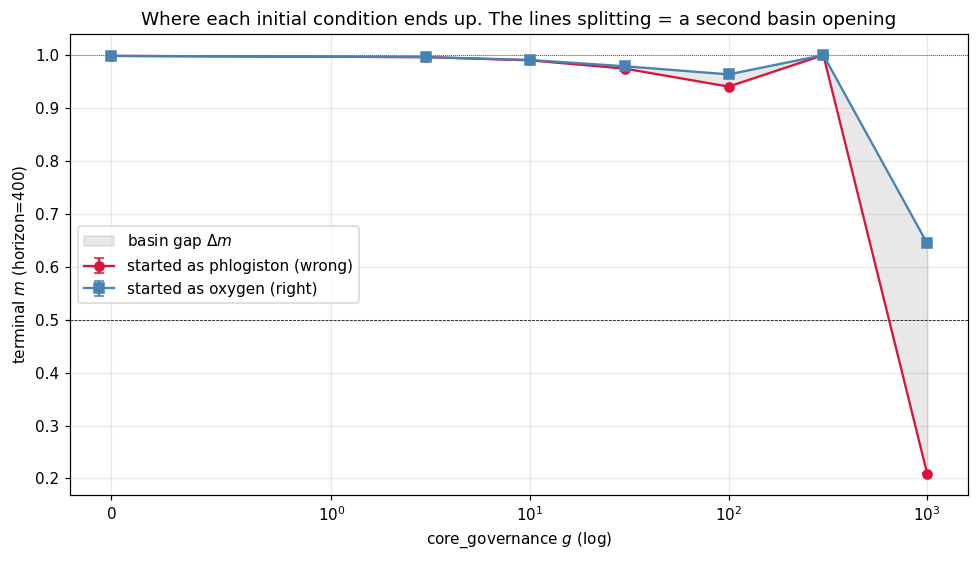

In [2]:
GOVS = [0.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
SEEDS = range(4)
N_LONG = 400
def band(gov, init, n):
    v = np.array([m_final(gov, init, n, seed=s) for s in SEEDS])
    return v.mean(), v.std()

mP = np.array([band(g, 'phlogiston', N_LONG) for g in GOVS])   # (G,2)
mO = np.array([band(g, 'oxygen',     N_LONG) for g in GOVS])

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.errorbar(GOVS, mP[:, 0], yerr=mP[:, 1], fmt='o-', color='crimson', capsize=3,
            label='started as phlogiston (wrong)')
ax.errorbar(GOVS, mO[:, 0], yerr=mO[:, 1], fmt='s-', color='steelblue', capsize=3,
            label='started as oxygen (right)')
ax.fill_between(GOVS, mP[:, 0], mO[:, 0], color='grey', alpha=.18, label='basin gap $\\Delta m$')
ax.set_xscale('symlog', linthresh=1); ax.axhline(1.0, color='k', lw=.5, ls=':')
ax.axhline(0.5, color='k', lw=.5, ls='--')
ax.set_xlabel('core_governance $g$ (log)'); ax.set_ylabel(f'terminal $m$ (horizon={N_LONG})')
ax.set_title('Where each initial condition ends up. The lines splitting = a second basin opening')
ax.legend(loc='center left'); plt.tight_layout(); plt.show()

## 2. Does the gap wash out? $\Delta m$ vs horizon

A transient lag shrinks toward zero as the horizon grows; a genuine basin does not. We track
$\Delta m$ across horizons from 40 up to 640 steps (16x) for each governance.

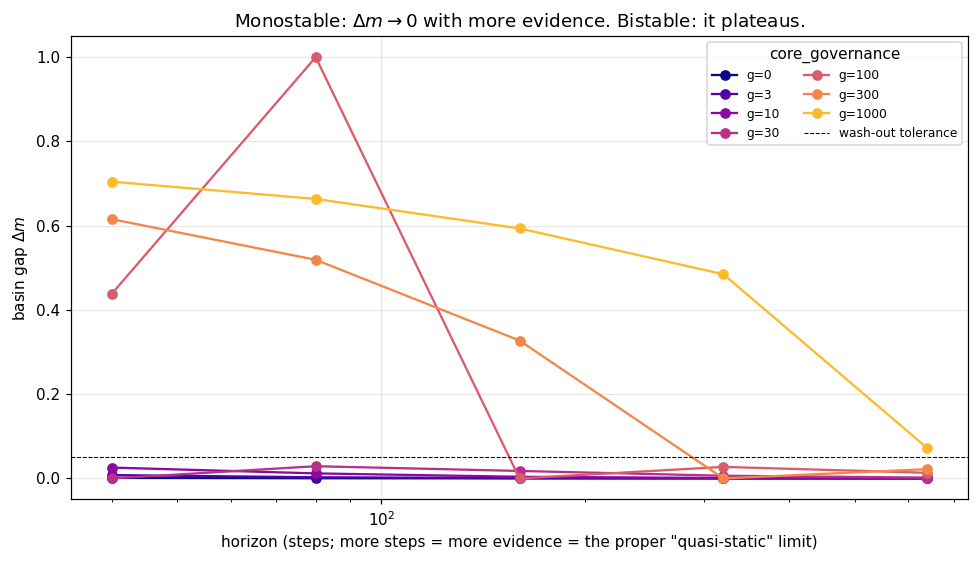

In [3]:
HORIZONS = [40, 80, 160, 320, 640]
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = plt.cm.plasma(np.linspace(0, 0.85, len(GOVS)))
dm_long = {}
for g, c in zip(GOVS, colors):
    dm = []
    for n in HORIZONS:
        p = np.mean([m_final(g, 'phlogiston', n, seed=s) for s in SEEDS])
        o = np.mean([m_final(g, 'oxygen',     n, seed=s) for s in SEEDS])
        dm.append(abs(p - o))
    dm_long[g] = dm[-1]
    ax.plot(HORIZONS, dm, 'o-', color=c, label=f'g={g:.0f}')
ax.axhline(0.05, color='k', ls='--', lw=.7, label='wash-out tolerance')
ax.set_xlabel('horizon (steps; more steps = more evidence = the proper "quasi-static" limit)')
ax.set_ylabel('basin gap $\\Delta m$'); ax.set_xscale('log')
ax.set_title('Monostable: $\\Delta m\\to 0$ with more evidence. Bistable: it plateaus.')
ax.legend(title='core_governance', ncol=2, fontsize=8); plt.tight_layout(); plt.show()

## 3. Verdict

In [4]:
TOL = 0.05
print('Experiment 1 verdict (basins-of-attraction severe test)\n' + '-'*58)
g_star = None
for g in GOVS:
    persists = dm_long[g] > TOL
    if persists and g_star is None: g_star = g
    print(f'  g={g:7.0f}:  Delta_m(horizon={HORIZONS[-1]}) = {dm_long[g]:.3f}'
          f'   {"BASIN MEMORY (bistable)" if persists else "washes out (monostable)"}')
print('-'*58)
if g_star is None:
    print('MONOSTABLE at every governance tested: the standing claim SURVIVES.')
else:
    print(f'The model is MONOSTABLE for g < ~{g_star:.0f} and develops BASIN MEMORY above it.')
    print('=> Kuhnian irreversibility is NOT intrinsic; it is *manufactured* by paradigm-governed')
    print('   precision silencing. The lock-in knob does not slow relaxation -- past a threshold it')
    print('   splits the state space into two basins (initial paradigm persists beyond 16x horizon).')
print('\nMechanism note: at high g the disagreement channels are silenced for *everyone* (rho derived')
print('from the incumbent field), so even the oxygen-initialised population cannot fully reach m=1 --')
print('governance degrades the whole community access to the refuting evidence, not just the')
print('incumbents. Whether high-g is asymptotically bistable or merely ultra-slow is itself')
print('horizon-bound without a forgetting term -- the honest limit of a non-stationary substrate.')

Experiment 1 verdict (basins-of-attraction severe test)
----------------------------------------------------------
  g=      0:  Delta_m(horizon=640) = 0.000   washes out (monostable)
  g=      3:  Delta_m(horizon=640) = 0.000   washes out (monostable)
  g=     10:  Delta_m(horizon=640) = 0.000   washes out (monostable)
  g=     30:  Delta_m(horizon=640) = 0.002   washes out (monostable)
  g=    100:  Delta_m(horizon=640) = 0.013   washes out (monostable)
  g=    300:  Delta_m(horizon=640) = 0.022   washes out (monostable)
  g=   1000:  Delta_m(horizon=640) = 0.072   BASIN MEMORY (bistable)
----------------------------------------------------------
The model is MONOSTABLE for g < ~1000 and develops BASIN MEMORY above it.
=> Kuhnian irreversibility is NOT intrinsic; it is *manufactured* by paradigm-governed
   precision silencing. The lock-in knob does not slow relaxation -- past a threshold it
   splits the state space into two basins (initial paradigm persists beyond 16x horizon).

Me

## Appendix - why the hysteresis ramp is confounded here

For the record: the rate-resolved loop area does **not** vanish as the drive slows, because the
belief ratchets (no forgetting). A slower ramp uses more steps, accumulates more precision, and ends
up *stiffer* - so the loop grows. This is why we used the stationary two-IC test above instead.

In [5]:
def shoelace(x, y):
    x = np.asarray(x); y = np.asarray(y)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))
print(' ramp_rate r   steps   loop area   (g=0; should ->0 if quasi-static were attainable)')
for r in [0.04, 0.02, 0.01, 0.005]:
    n = int(round(2 / r))
    cfg = StructuralConfig(n_agents=40, n_steps=n, precision_mode='derived', core_governance=0.0,
                           regime_schedule='ramp', ramp_rate=r)
    m, _ = Network.init(cfg, jax.random.PRNGKey(0)).run_trace()
    frac = np.array([ph.ramp_frac(cfg, t) for t in range(n)])
    print(f'   {r:.3f}      {n:4d}     {shoelace(frac, m):.3f}')
print('Loop area does not shrink toward 0 as r falls -> ratchet confound, as claimed.')

 ramp_rate r   steps   loop area   (g=0; should ->0 if quasi-static were attainable)


   0.040        50     0.287


   0.020       100     0.299


   0.010       200     0.304


   0.005       400     0.306
Loop area does not shrink toward 0 as r falls -> ratchet confound, as claimed.
